# Projet de Scoring Crédit  
## Analyse exploratoire des données (EDA)

**Auteur : Laveus Mick-Wanderly**  
**Formation : Master Mathématiques & Informatique – orientation Data**  
**Objectif : Évaluation du risque de défaut de paiement**

<img src="../reports/p43.jpg" style="width:100%; border-radius:12px;">



Lorsqu’une **banque** prête de l’argent à une personne, elle prend le risque que cette dernière ne rembourse pas le montant emprunté dans le **délai convenu**. Ce risque est appelé **risque de crédit**. Avant d’octroyer un crédit, les banques vérifient si le client ou la cliente qui en fait la demande sera **capable de rembourser** le prêt.

Cette évaluation repose sur l’analyse de plusieurs **paramètres financiers et socio-économiques**, tels que les **revenus**, les **biens**, les **dépenses actuelles** ou encore la **situation professionnelle** du client. Dans de nombreuses banques, cette analyse est encore réalisée **manuellement**, ce qui la rend **très consommatrice en temps** et en **ressources financières**.

Grâce au **machine learning**, il est désormais possible d’**automatiser cette tâche** et de **prédire avec une meilleure précision** les clients susceptibles d’être en **défaut de paiement**.

Dans ce projet, nous allons construire un **algorithme de scoring crédit** capable de prédire si une personne sera en **défaut de paiement** ou non (**1 : défaut**, **0 : non-défaut**). Il s’agit donc d’un **problème de classification**, puisque l’objectif est de prédire une **variable discrète binaire**.


## Importation des bibliothèques et des données


In [28]:
# Importation du module sys pour vérifier l’interpréteur Python utilisé
import sys

# Affiche le chemin de l’exécutable Python afin de s’assurer que l’environnement virtuel du projet est bien utilisé
sys.executable


'/home/dev/projects/credit-scoring/.venv/bin/python'

In [29]:
# Importation de la bibliothèque pandas pour la manipulation et l’analyse des données
import pandas as pd

En ce qui concerne les **données**, il s’agit d’informations collectées sur d’**anciens clients** ayant contracté des **prêts**, et qui sont utilisées afin de **prédire le comportement des nouveaux clients**.

Deux (**02**) grands types de données peuvent être utilisés pour **modéliser la probabilité de défaut de paiement** :

- **Données liées à la demande de crédit** : informations fournies par le client au moment de la demande, telles que les **revenus**, la **situation professionnelle**, le **montant du crédit** ou la **durée du prêt**.
- **Données comportementales** décrivant le **bénéficiaire du prêt** : informations reflétant le **comportement passé du client**, comme l’**historique de remboursement**, la **gestion des comptes** ou les **antécédents de crédit**.

Dans la **pratique bancaire**, les établissements financiers utilisent généralement un **mélange de ces deux types de données** afin de construire leur **modèle de scoring crédit**, appliqué à la **gestion du risque de crédit**.


In [30]:
#Importation des données 

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "status_account", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment", "installment_rate", "personal_status_sex",
    "other_debtors", "residence_since", "property", "age",
    "other_installment_plans", "housing", "existing_credits",
    "job", "num_dependents", "own_telephone", "foreign_worker", "target"
]

df = pd.read_csv(url, sep=" ", names=columns)
df.head()



,status_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [31]:

df.columns

Index(['status_account', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings', 'employment', 'installment_rate',
       'personal_status_sex', 'other_debtors', 'residence_since', 'property',
       'age', 'other_installment_plans', 'housing', 'existing_credits', 'job',
       'num_dependents', 'own_telephone', 'foreign_worker', 'target'],
      dtype='object')

Les données utilisées dans ce projet proviennent du jeu de données **German Credit**, largement utilisé dans la littérature en **scoring crédit** et en **apprentissage automatique**. Ce jeu de données regroupe des informations collectées sur d’anciens clients ayant contracté un **crédit bancaire**.

L’ensemble des données est composé de **21 variables** et de **1 000 observations** historiques. Chaque observation correspond à une **personne ayant contracté un prêt**. Certaines variables décrivent les **caractéristiques du crédit** (montant, durée, type de prêt, etc.), tandis que d’autres décrivent les **caractéristiques personnelles et financières du client** (âge, situation professionnelle, historique de crédit, etc.).

Ces **données historiques** sont utilisées afin de construire un **modèle de scoring crédit**, dont l’objectif est de **prédire le risque de défaut de paiement** des nouveaux candidats à un crédit. Il est donc essentiel de bien **comprendre les variables** constituant ce jeu de données avant toute étape de modélisation.


Les variables du jeu de données sont décrites ci-dessous :

- **status_account** : statut du compte bancaire du client (niveau de solde et ancienneté)
- **duration** : durée du crédit (en mois)
- **credit_history** : historique de crédit du client (comportement de remboursement passé)
- **purpose** : objectif du crédit (achat de biens, voiture, équipements, etc.)
- **credit_amount** : montant total du crédit accordé
- **savings** : niveau d’épargne du client
- **employment** : ancienneté professionnelle du client
- **installment_rate** : taux des mensualités par rapport au revenu
- **personal_status_sex** : situation personnelle et sexe du client
- **other_debtors** : présence d’autres débiteurs ou garants
- **residence_since** : durée de résidence à l’adresse actuelle
- **property** : type de biens possédés par le client
- **age** : âge du client
- **other_installment_plans** : existence d’autres plans de remboursement
- **housing** : situation de logement (locataire, propriétaire, etc.)
- **existing_credits** : nombre de crédits existants au moment de la demande
- **job** : type d’emploi occupé par le client
- **num_dependents** : nombre de personnes à charge
- **own_telephone** : possession d’un téléphone
- **foreign_worker** : statut de travailleur étranger
- **target** : variable cible indiquant si le client est en **défaut de paiement** (1) ou non (0)

Passons à l'analyse exploratoire des données qui nous permettra de mieux les comprendre.

## Analyse exploratoire et des données

In [32]:
# Résumé statistique des variables numériques du jeu de données
df.describe()


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


**Légende du résumé statistique :**  
- **count** : nombre d’observations disponibles pour chaque variable  
- **mean** : valeur moyenne  
- **std** : écart-type, mesurant la dispersion des données autour de la moyenne  
- **min** : valeur minimale observée  
- **25 % / 50 % / 75 %** : quartiles de la distribution (la valeur à **50 %** correspond à la **médiane**)  
- **max** : valeur maximale observée


### Interprétation du résumé statistique

Le jeu de données contient **1 000 observations**, ce qui correspond à **1 000 clients** ayant contracté un crédit. Aucune valeur manquante n’est observée pour les variables numériques analysées.

La **durée moyenne du crédit** est d’environ **21 mois**, avec une médiane de **18 mois**, ce qui indique que la majorité des prêts sont de **court à moyen terme**, bien que certains crédits puissent aller jusqu’à **72 mois**.

Le **montant moyen du crédit** s’élève à environ **3 271 unités monétaires**, avec une forte **dispersion** (écart-type élevé). Les montants varient fortement, allant de **250** à plus de **18 000**, ce qui traduit une **hétérogénéité importante des profils de crédit**.

Le **taux des mensualités** par rapport au revenu (`installment_rate`) est compris entre **1 et 4**, avec une médiane de **3**, suggérant que la majorité des clients supporte une charge de remboursement modérée à élevée.

L’**âge moyen des clients** est d’environ **36 ans**, avec une médiane de **33 ans**. La population étudiée est donc principalement composée d’**adultes actifs**, bien que certains clients puissent être relativement jeunes ou proches de l’âge de la retraite.

Le nombre de **crédits existants** est en moyenne de **1 à 2**, ce qui indique que la plupart des clients ne sont pas fortement endettés au moment de la demande de crédit. De même, la majorité des clients possède **une seule personne à charge**.

Enfin, la variable cible `target` montre que la majorité des clients appartient à la classe **sans défaut de paiement**, tandis qu’une proportion plus faible correspond aux clients en **défaut**, ce qui suggère un **déséquilibre modéré des classes**, caractéristique des problèmes de **scoring crédit**.


In [33]:
df.isnull().sum()


status_account             0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings                    0
employment                 0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
num_dependents             0
own_telephone              0
foreign_worker             0
target                     0
dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment               1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

L’analyse des données montre qu’aucune variable ne contient de **valeurs manquantes**, comme le confirme la méthode `df.isnull().sum()`. L’ensemble des colonnes comporte **1 000 observations**, indiquant un **jeu de données complet**. La commande `df.info()` confirme cette observation et met en évidence une **structure cohérente** du jeu de données, composée de variables **numériques** et **catégorielles** correctement définies. Aucun traitement spécifique lié aux valeurs manquantes n’est donc nécessaire avant la phase de modélisation.

Par ailleurs, l’examen des **statistiques descriptives** ne révèle pas de **valeurs aberrantes évidentes**. Les plages de valeurs observées pour l’**âge**, la **durée du crédit**, le **montant du prêt** et les autres variables sont cohérentes avec un **contexte bancaire réel**. Certaines variables, notamment le **montant du crédit**, présentent toutefois une **forte dispersion**, traduisant une **hétérogénéité des profils clients**, qui devra être prise en compte lors de la **modélisation**.


Passons à l'analyse de la variable cible target.

In [35]:
df["target"].value_counts()


target
1    700
2    300
Name: count, dtype: int64

In [36]:
df["target"].value_counts(normalize=True) * 100


target
1    70.0
2    30.0
Name: proportion, dtype: float64

In [45]:
#Transformer la variable cible pour la modélisation

df["target"] = df["target"].map({1:0 , 2 : 1}) 
df["target"].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

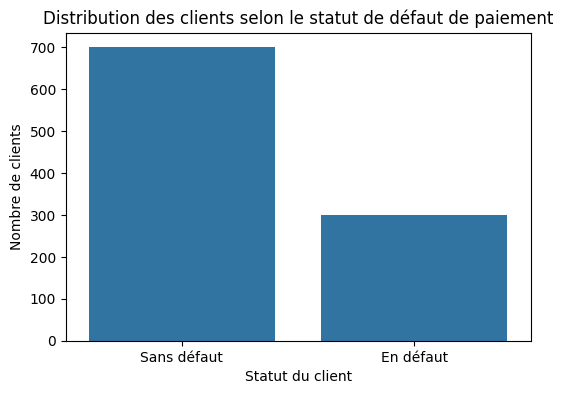

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)

plt.title("Distribution des clients selon le statut de défaut de paiement")
plt.xlabel("Statut du client")
plt.ylabel("Nombre de clients")
plt.xticks([0, 1], ["Sans défaut", "En défaut"])

plt.show()


L’analyse de la variable cible montre que le jeu de données contient **700 clients sans défaut de paiement** et **300 clients en défaut**, soit environ **70 % de bons clients** contre **30 % de clients en défaut**. Cette distribution met en évidence un **déséquilibre modéré des classes**, caractéristique des problèmes de **scoring crédit**, qui devra être pris en compte lors de la modélisation. 
Si le déséquillibre observé ici est tout à fait normal. Il n'en demeurre moins que cela représente un grand défi de classsification pour les algorithmes de Machine Learning.
